In [19]:
import pandas as pd
import numpy as np
from collections import defaultdict
import networkx as nx
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import fisher_exact
from itertools import combinations

In [20]:
# load the clustered SV regions file
clustered_sv = pd.read_csv('../results/all_samples_clustering_regions.txt', sep='\t')
clustered_sv = clustered_sv[['chr', 'start.bp', 'end.bp', 'length.bp', 'number.bps', 'sample']]
clustered_sv['chr'] = clustered_sv['chr'].astype(str).replace({'23': 'X', '24': 'Y'})

clustered_sv['cluster_id'] = clustered_sv.apply(
    lambda r: f"{r['sample']}_{r['chr']}_{int(r['start.bp'])}_{int(r['end.bp'])}", axis=1
)
clustered_sv.head()

,chr,start.bp,end.bp,length.bp,number.bps,sample,cluster_id
0,3,116621819,117141088,519269,11,09T02-09N01,09T02-09N01_3_116621819_117141088
1,4,13471388,18732304,5260916,29,09T02-09N01,09T02-09N01_4_13471388_18732304
2,4,25072669,26958517,1885848,13,09T02-09N01,09T02-09N01_4_25072669_26958517
3,4,33510366,34040322,529956,12,09T02-09N01,09T02-09N01_4_33510366_34040322
4,8,54141094,54269718,128624,10,09T02-09N01,09T02-09N01_8_54141094_54269718


In [21]:
# load included samples files
final_samples = pd.read_csv('../../../SV_sample_data/data/final_samples.csv')
analysis_samples = pd.read_csv('../../../SV_sample_data/data/final_analysis_samples.csv') # unique participant samples
# load all SVs file
svs = pd.read_csv('../../../SV_sample_data/data/sv_file_v2.csv')
svs = svs[svs['name'].isin(final_samples['tumor_normal_pair'])]
print(f"Total samples with SVs: {svs['name'].nunique()}")
svs.head()

Total samples with SVs: 234


,num,chr1,str1,pos1,chr2,str2,pos2,class,span,somatic,somatic_score,SvABA,Manta,VCF_TALT,VCF_NALT,VCF_TREF,VCF_NREF,name
0,614,1,0,3680543,1,1,3731731,deletion,51189.0,1,15.0,0,1,11,0,149,86,09T02-09N01
1,615,1,0,25148899,1,1,25252735,deletion,103843.0,1,15.0,0,1,12,0,126,72,09T02-09N01
2,909,1,0,124154195,1,1,124163217,deletion,9022.0,1,5.0,0,1,9,0,199,69,09T02-09N01
3,719,1,1,160827717,1,0,160890810,tandem_dup,63090.0,1,11.0,0,1,15,0,163,65,09T02-09N01
4,33,1,1,246260290,19,1,6750721,inter_chr,NaN,1,41.0,1,1,25,0,127,73,09T02-09N01


In [22]:
# 1. If linked events are on the same chromosome, merge these clusters and adjust coordinates
LINK_WINDOW_BP = 10_000
MIN_LINKS      = 2

def parse_cluster(cid):
    parts = cid.rsplit('_', 3)
    return parts[0], parts[1], int(parts[2]), int(parts[3])  # sample, chr, start, end

# (sample, chr) → [(start, end, id), ...]
def build_index(id_list):
    idx = defaultdict(list)
    for cid in id_list:
        sample, chrom, start, end = parse_cluster(cid)
        idx[(sample, chrom)].append((start, end, cid))
    return idx

def nearby(idx, sample, chrom, pos, window=LINK_WINDOW_BP):
    return [
        cid for (start, end, cid) in idx.get((sample, chrom), [])
        if (pos - window) <= end and (pos + window) >= start
    ]

# index the original clusters
cluster_idx = build_index(clustered_sv['cluster_id'])

# loop through SVs, collect intra-chr edges only
G = nx.Graph()
for cid in clustered_sv['cluster_id']:
    G.add_node(cid)

for _, sv in svs.iterrows():
    sample = sv['name']
    if pd.isna(sample) or str(sv['chr1']) != str(sv['chr2']):
        continue      # skip inter-chr SVs

    hits1 = nearby(cluster_idx, sample, str(sv['chr1']), sv['pos1'])
    hits2 = nearby(cluster_idx, sample, str(sv['chr2']), sv['pos2'])

    for c1 in hits1:
        for c2 in hits2:
            if c1 != c2:
                G.add_edge(c1, c2)

# merge connected components
merged_events = []
for component in nx.connected_components(G):
    parsed    = [parse_cluster(c) for c in component]
    sample    = parsed[0][0]
    chrom     = parsed[0][1]
    mrg_start = min(p[2] for p in parsed)
    mrg_end   = max(p[3] for p in parsed)
    event_id  = f"{sample}_{chrom}_{mrg_start}_{mrg_end}"

    merged_events.append({
        'sample':          sample,
        'chr':             chrom,
        'start':           mrg_start,
        'end':             mrg_end,
        'event_id':        event_id,
        'source_clusters': sorted(component),
        'n_merged':        len(component),
    })

merged_df = (
    pd.DataFrame(merged_events)
    .sort_values(['sample', 'chr', 'start'])
    .reset_index(drop=True)
)

merged_df.to_csv('../results/merged_clustered_sv_events.csv', index=False)
print(f"Merged events: {len(merged_df)}  (from {len(clustered_sv)} original clusters)")
merged_df[merged_df['n_merged'] > 1]

Merged events: 1173  (from 1692 original clusters)


,sample,chr,start,end,event_id,source_clusters,n_merged
5,09T02-09N01,4,13471388,34040322,09T02-09N01_4_13471388_34040322,"[09T02-09N01_4_13471388_18732304, 09T02-09N01_...",3
12,10T03-10N02,1,39124815,116039435,10T03-10N02_1_39124815_116039435,"[10T03-10N02_1_115194818_116039435, 10T03-10N0...",4
13,10T03-10N02,2,94759870,185993428,10T03-10N02_2_94759870_185993428,"[10T03-10N02_2_125490979_127242160, 10T03-10N0...",5
14,13T02-13N02,12,30307818,88808948,13T02-13N02_12_30307818_88808948,"[13T02-13N02_12_30307818_34191200, 13T02-13N02...",4
16,13T02-13N02,16,59617053,82675792,13T02-13N02_16_59617053_82675792,"[13T02-13N02_16_59617053_63013016, 13T02-13N02...",2
...,...,...,...,...,...,...,...
1140,TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A,6,44951783,95944937,TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A_6_44...,[TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A_6_4...,3
1151,TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A,8,119973285,132142548,TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A_8_11...,[TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A_8_1...,3
1152,TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A,9,15041713,24720597,TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A_9_15...,[TARGET-40-PATUXZ-01A-TARGET-40-PATUXZ-10A_9_1...,2
1155,WGS_12_19-WGS_11_17,14,47706637,69173599,WGS_12_19-WGS_11_17_14_47706637_69173599,"[WGS_12_19-WGS_11_17_14_47706637_51883317, WGS...",2


Clustered regions per sample statistics:
Samples with clustered SVs: 181
Min: 1
25th percentile: 2
50th percentile (Median): 4
75th percentile: 7
Max: 42


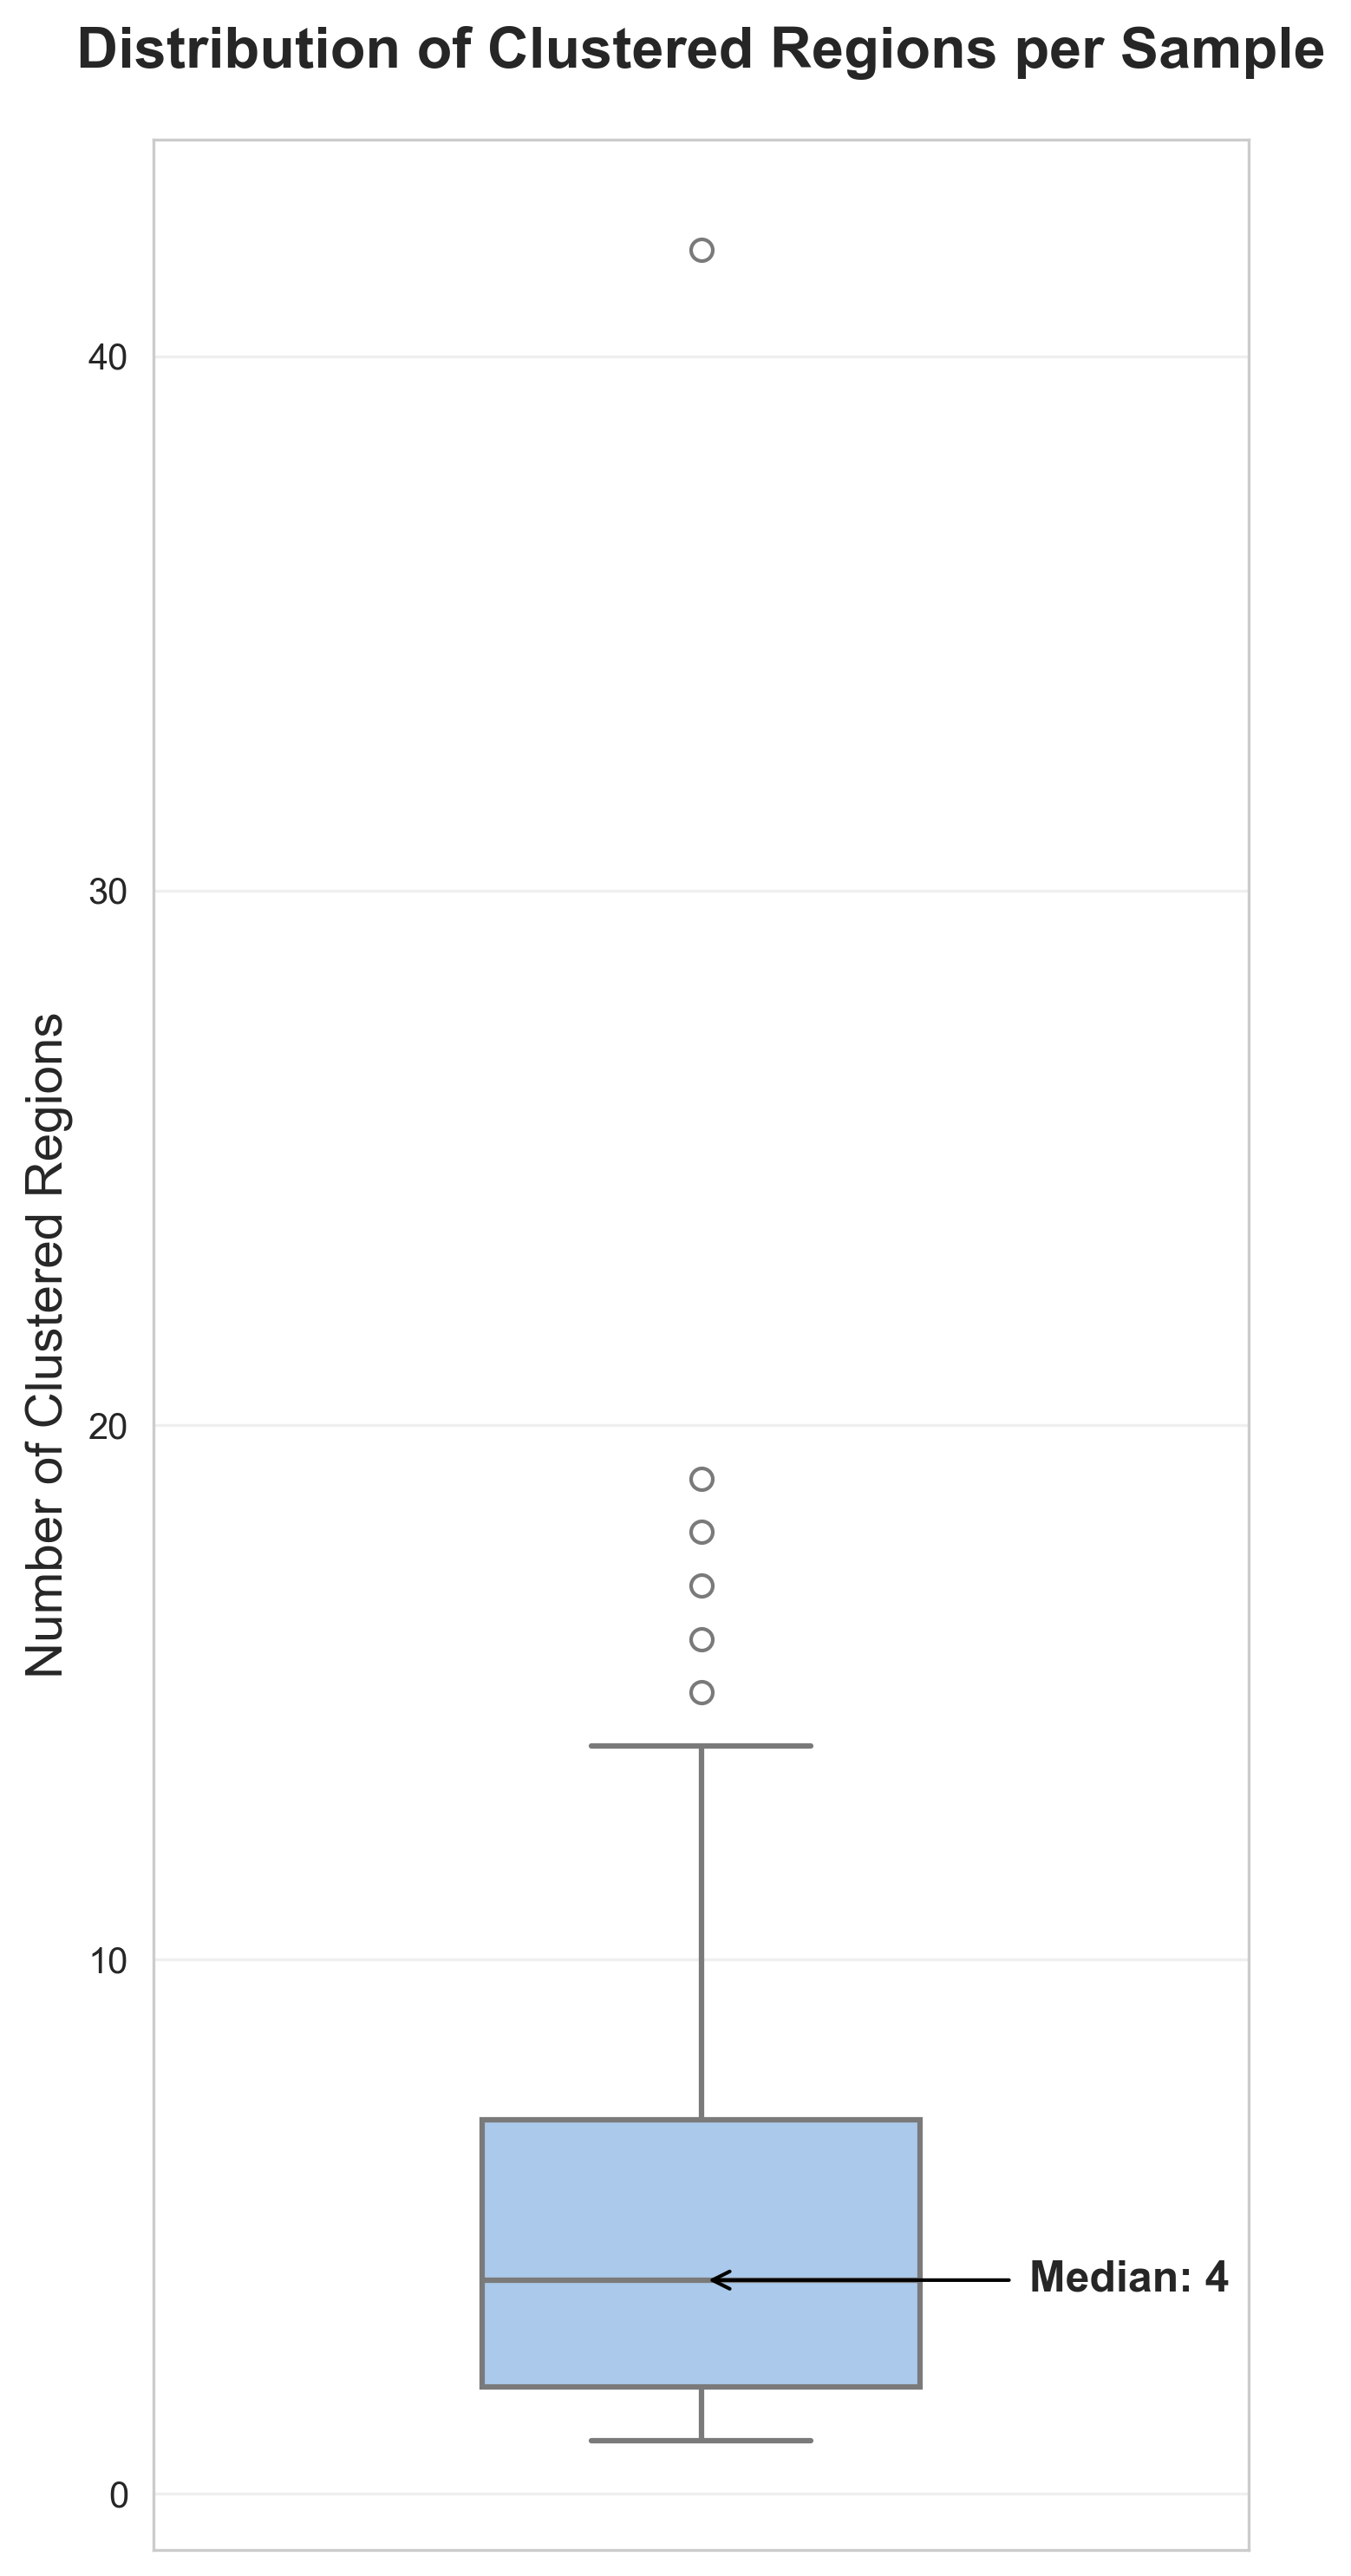

In [23]:
# Get the count of clustered regions per sample (only including samples with clustered SVs)
clustered_counts = merged_df[merged_df['sample'].isin(analysis_samples['tumor_normal_pair'])]['sample'].value_counts().reset_index()
clustered_counts.columns = ['sample', 'clustered_region_count']

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Create the vertical boxplot
plt.figure(figsize=(5, 10))
box_plot = sns.boxplot(y=clustered_counts['clustered_region_count'], color=sns.color_palette("pastel")[0], linewidth=1.5, width=0.4)

plt.title('Distribution of Clustered Regions per Sample', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Clustered Regions', fontsize=14)
plt.xlabel('')

# Annotate median
median_value = clustered_counts['clustered_region_count'].median()
plt.annotate(f'Median: {median_value:.0f}', 
            xy=(0, median_value), 
            xytext=(0.3, median_value),
            fontsize=12,
            fontweight='bold',
            ha='left',
            va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='black', lw=1))


plt.tick_params(axis='y', labelsize=10)
plt.grid(True, alpha=0.3, axis='y', linewidth=0.8)
plt.tight_layout()

print(f"Clustered regions per sample statistics:")
stats = {
    'Samples with clustered SVs': len(clustered_counts),
    'Min': clustered_counts['clustered_region_count'].min(),
    '25th percentile': clustered_counts['clustered_region_count'].quantile(0.25),
    '50th percentile (Median)': clustered_counts['clustered_region_count'].quantile(0.5),
    '75th percentile': clustered_counts['clustered_region_count'].quantile(0.75),
    'Max': clustered_counts['clustered_region_count'].max()
}
for stat, value in stats.items():
    if 'Count' in stat:
        print(f"{stat}: {value}")
    else:
        print(f"{stat}: {value:.0f}")

plt.show()

In [25]:
# index merged events, loop through SVs for inter-chr links
event_idx = build_index(merged_df['event_id'])

G2 = nx.Graph()
for eid in merged_df['event_id']:
    G2.add_node(eid)

for _, sv in svs.iterrows():
    sample = sv['name']
    if pd.isna(sample) or str(sv['chr1']) == str(sv['chr2']):
        continue

    hits1 = nearby(event_idx, sample, str(sv['chr1']), sv['pos1'])
    hits2 = nearby(event_idx, sample, str(sv['chr2']), sv['pos2'])

    for e1 in hits1:
        for e2 in hits2:
            if e1 != e2:
                G2.add_edge(e1, e2)

# merge inter-chr connected components to form the final events
final_events = []
for i, component in enumerate(nx.connected_components(G2)):
    # pull metadata for each merged_df event in this component
    members = merged_df[merged_df['event_id'].isin(component)]
    
    # all source clusters across all members
    all_clusters = [c for clusters in members['source_clusters'] for c in clusters]
    chromosomes = sorted(members['chr'].unique(), key=lambda x: int(x) if x.isdigit() else x)
    sample = members['sample'].iloc[0]

    final_events.append({
        'event_idx':       i,
        'sample':          sample,
        'n_chromosomes':   len(chromosomes),
        'chromosomes':     chromosomes,
        'n_clusters':      len(all_clusters),
        'source_clusters': sorted(all_clusters),
        'component_events': sorted(component),   # the merged intra-chr events
        'is_inter_chr':      len(component) > 1,   # touches >1 chr region
    })

final_df = (
    pd.DataFrame(final_events)
    .sort_values(['sample', 'n_chromosomes', 'n_clusters'], ascending=[True, False, False])
    .reset_index(drop=True)
)

print(f"Total final events: {len(final_df)}")
print(f"  Single-chr, single-cluster: {len(final_df[~final_df['is_inter_chr'] & (final_df['n_clusters']==1)])}")
print(f"  Single-chr, multi-cluster:  {len(final_df[~final_df['is_inter_chr'] & (final_df['n_clusters']>1)])}")
print(f"  Multi-chr:                  {len(final_df[final_df['is_inter_chr']])}")
final_df.to_csv('../results/final_clustered_sv_events.csv', index=False)
final_df.head()

Total final events: 701
  Single-chr, single-cluster: 464
  Single-chr, multi-cluster:  60
  Multi-chr:                  177


,event_idx,sample,n_chromosomes,chromosomes,n_clusters,source_clusters,component_events,is_inter_chr
0,1,09T02-09N01,3,"[8, 19, 21]",3,"[09T02-09N01_19_9538321_11079287, 09T02-09N01_...","[09T02-09N01_19_9538321_11079287, 09T02-09N01_...",True
1,2,09T02-09N01,2,"[4, 19]",4,"[09T02-09N01_19_56370219_57632870, 09T02-09N01...","[09T02-09N01_19_56370219_57632870, 09T02-09N01...",True
2,0,09T02-09N01,1,[11],1,[09T02-09N01_11_25810096_32598616],[09T02-09N01_11_25810096_32598616],False
3,3,09T02-09N01,1,[3],1,[09T02-09N01_3_116621819_117141088],[09T02-09N01_3_116621819_117141088],False
4,4,09T02-09N01,1,[8],1,[09T02-09N01_8_54141094_54269718],[09T02-09N01_8_54141094_54269718],False


In [26]:
# Create a table, that shows for each sample (including multiple tumors), the number of clustered SVs and the hotspot clustered SV events it has
def check_overlap(event, chrom, start, end):
    return (chrom == event["chrom"] and 
            not (end < event["start"] or start > event["end"]))

def create_binary_matrix(clustered_file, events_dict, final_samples):
    df = pd.read_csv(clustered_file)

    # define the full cohort (include samples with 0 clustered SVs)
    samples = final_samples['tumor_normal_pair'].dropna().unique()

    # keep only rows in-cohort (but don’t use this to define samples)
    df = df[df['sample'].isin(samples)]
    print(f"Total samples (final_samples): {len(samples)}")
    print(f"Samples with >=1 clustered SV row: {df['sample'].nunique()}")

    matrix = pd.DataFrame(0, index=samples, columns=events_dict.keys())

    # make chr types consistent
    df['chr'] = df['chr'].astype(str)
    events_dict = {k: {**v, "chrom": str(v["chrom"])} for k, v in events_dict.items()}

    for _, row in df.iterrows():
        sample = row['sample']
        chrom = row['chr']
        start = row['start']
        end = row['end']

        for event_name, event_coords in events_dict.items():
            if check_overlap(event_coords, chrom, start, end):
                matrix.loc[sample, event_name] = 1

    # number of clustered SV rows per sample (0 if none)
    clustered_counts = df.groupby('sample').size()
    matrix['n_clustered_regions'] = clustered_counts.reindex(matrix.index).fillna(0).astype(int)

    return matrix

events_df = pd.read_csv('../results/hotspot_event_definitions.csv')
events = (
    events_df
    .set_index('event')[['chrom', 'start', 'end']]
    .to_dict(orient='index')
)
matrix = create_binary_matrix('../results/merged_clustered_sv_events.csv', events, final_samples)

# per-hotspot summary table
event_cols = list(events.keys())
hotspot_summary = pd.DataFrame({
    "n_samples_hit": matrix[event_cols].sum(axis=0).astype(int),
})
hotspot_summary["fraction_samples_hit"] = hotspot_summary["n_samples_hit"] / matrix.shape[0]

print("\nPer-hotspot summary:")
print(hotspot_summary.sort_values("n_samples_hit", ascending=False))

matrix.reset_index(inplace=True)
matrix.rename(columns={'index': 'sample_id'}, inplace=True)
matrix.to_csv('../results/clustered_sv_merged_hotspot_matrix.csv', index=False)

# per-hotspot summary table (analysis samples only)
matrix_analysis = matrix[matrix['sample_id'].isin(analysis_samples['tumor_normal_pair'])]
hotspot_summary = pd.DataFrame({
    "n_samples_hit": matrix_analysis[event_cols].sum(axis=0).astype(int),
})
hotspot_summary["fraction_samples_hit"] = hotspot_summary["n_samples_hit"] / matrix_analysis.shape[0]

print("\nPer-hotspot summary (analysis samples only):")
print(hotspot_summary.sort_values("n_samples_hit", ascending=False))

print(f"Total samples with at least one hotspot event: {(matrix_analysis[event_cols].sum(axis=1) > 0).sum()}")
print(f"Total samples with multiple hotspot events: {(matrix_analysis[event_cols].sum(axis=1) > 1).sum()}")
matrix_analysis.head()

Total samples (final_samples): 236
Samples with >=1 clustered SV row: 209

Per-hotspot summary:
           n_samples_hit  fraction_samples_hit
TP53                  60              0.254237
MYC                   47              0.199153
CCND3                 41              0.173729
CCNE1                 37              0.156780
CDK4-MDM2             24              0.101695

Per-hotspot summary (analysis samples only):
           n_samples_hit  fraction_samples_hit
TP53                  51              0.246377
MYC                   38              0.183575
CCNE1                 35              0.169082
CCND3                 33              0.159420
CDK4-MDM2             23              0.111111
Total samples with at least one hotspot event: 119
Total samples with multiple hotspot events: 50


,sample_id,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_regions
0,09T02-09N01,0,1,0,0,0,8
2,10T03-10N02,0,0,0,0,0,2
3,13T02-13N02,0,0,1,1,0,8
4,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3
5,17_439_00097_T1-17_439_00097_WB,0,0,0,0,0,0


In [27]:
# annotate the final_df to see which hotspot each "final" event overlaps
def parse_component(cid):
    parts = cid.split("_")
    chr_, start, end = parts[-3], int(parts[-2]), int(parts[-1])
    return chr_, start, end

def event_overlaps_hotspot(component_events_val, hotspot):
    comp_list = ast.literal_eval(component_events_val) if isinstance(component_events_val, str) else component_events_val
    h = {**hotspot, "chrom": str(hotspot["chrom"])}
    for cid in comp_list:
        c_chr, c_start, c_end = parse_component(cid)
        if check_overlap(h, c_chr, c_start, c_end):
            return True
    return False

for name, region in events.items():
    final_df[name] = final_df["component_events"].apply(
        lambda ce, r=region: 1 if event_overlaps_hotspot(ce, r) else 0
    )
final_df.to_csv('../results/final_clustered_sv_events.csv', index=False)
final_df.head()

,event_idx,sample,n_chromosomes,chromosomes,n_clusters,source_clusters,component_events,is_inter_chr,CCND3,MYC,CDK4-MDM2,CCNE1,TP53
0,1,09T02-09N01,3,"[8, 19, 21]",3,"[09T02-09N01_19_9538321_11079287, 09T02-09N01_...","[09T02-09N01_19_9538321_11079287, 09T02-09N01_...",True,0,1,0,0,0
1,2,09T02-09N01,2,"[4, 19]",4,"[09T02-09N01_19_56370219_57632870, 09T02-09N01...","[09T02-09N01_19_56370219_57632870, 09T02-09N01...",True,0,0,0,0,0
2,0,09T02-09N01,1,[11],1,[09T02-09N01_11_25810096_32598616],[09T02-09N01_11_25810096_32598616],False,0,0,0,0,0
3,3,09T02-09N01,1,[3],1,[09T02-09N01_3_116621819_117141088],[09T02-09N01_3_116621819_117141088],False,0,0,0,0,0
4,4,09T02-09N01,1,[8],1,[09T02-09N01_8_54141094_54269718],[09T02-09N01_8_54141094_54269718],False,0,0,0,0,0


In [28]:
# filter to analysis samples
final_df_analysis = final_df[final_df['sample'].isin(analysis_samples['tumor_normal_pair'])]
hotspot_cols = ['CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1', 'TP53']

# define the full cohort (include samples with 0 clustered SVs)
samples = analysis_samples['tumor_normal_pair'].dropna().unique()

print(f"Total samples (final_samples): {len(samples)}")
print(f"Samples with >=1 clustered SV row: {final_df_analysis['sample'].nunique()}")

print(f"Total final events: {len(final_df_analysis)}")
print(f"  Multi-chr:                  {len(final_df_analysis[final_df_analysis['is_inter_chr']])}")

clustered_counts = final_df_analysis['sample'].value_counts().reset_index()
clustered_counts.columns = ['sample', 'clustered_region_count']
print(f"Clustered SV events per sample statistics:")
stats = {
    '25th percentile': clustered_counts['clustered_region_count'].quantile(0.25),
    '50th percentile (Median)': clustered_counts['clustered_region_count'].quantile(0.5),
    '75th percentile': clustered_counts['clustered_region_count'].quantile(0.75),
    'Max': clustered_counts['clustered_region_count'].max()
}
for stat, value in stats.items():
    if 'Count' in stat:
        print(f"{stat}: {value}")
    else:
        print(f"{stat}: {value:.0f}")

Total samples (final_samples): 207
Samples with >=1 clustered SV row: 181
Total final events: 589
  Multi-chr:                  142
Clustered SV events per sample statistics:
25th percentile: 1
50th percentile (Median): 2
75th percentile: 4
Max: 36


In [29]:
# find multi-hotspot events
def hit_combo(row):
    return ' + '.join(sorted([c for c in hotspot_cols if row[c] == 1]))

multi_hotspot_events = final_df_analysis[final_df_analysis[hotspot_cols].sum(axis=1) > 1]
multi_hotspot_events['hotspot_combo'] = multi_hotspot_events.apply(hit_combo, axis=1)
multi_hotspot_events['hotspot_combo'].value_counts()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_22437/1375657397.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_hotspot_events['hotspot_combo'] = multi_hotspot_events.apply(hit_combo, axis=1)


hotspot_combo
CCND3 + TP53                9
CCNE1 + TP53                8
CCND3 + CDK4-MDM2           4
CCNE1 + MYC                 3
MYC + TP53                  3
CDK4-MDM2 + TP53            2
CCND3 + CDK4-MDM2 + TP53    2
CCNE1 + CDK4-MDM2           1
CCND3 + MYC                 1
CCNE1 + CDK4-MDM2 + MYC     1
CDK4-MDM2 + MYC             1
CCND3 + CCNE1               1
Name: count, dtype: int64

In [30]:
# this just looks at whether samples multiple hotspot clustered SV events (hotspots could be overlapped by same or different event)
def hit_combo(row):
    return ' + '.join(sorted([c for c in hotspot_cols if row[c] == 1]))

multi_hotspot_events = matrix_analysis[matrix_analysis[hotspot_cols].sum(axis=1) > 1]
multi_hotspot_events['hotspot_combo'] = multi_hotspot_events.apply(hit_combo, axis=1)
multi_hotspot_events['hotspot_combo'].value_counts()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_22437/2596374888.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_hotspot_events['hotspot_combo'] = multi_hotspot_events.apply(hit_combo, axis=1)


hotspot_combo
CCNE1 + TP53                      10
CCND3 + TP53                       9
CCND3 + CDK4-MDM2                  5
CCNE1 + MYC                        4
MYC + TP53                         4
CCND3 + CCNE1                      3
CCNE1 + CDK4-MDM2                  2
CCND3 + CDK4-MDM2 + TP53           2
CCNE1 + CDK4-MDM2 + MYC            2
CCND3 + MYC                        1
CCND3 + MYC + TP53                 1
CCNE1 + MYC + TP53                 1
CCND3 + CDK4-MDM2 + MYC + TP53     1
CCNE1 + CDK4-MDM2 + TP53           1
CDK4-MDM2 + TP53                   1
CCND3 + CDK4-MDM2 + MYC            1
CDK4-MDM2 + MYC                    1
CCND3 + CCNE1 + TP53               1
Name: count, dtype: int64

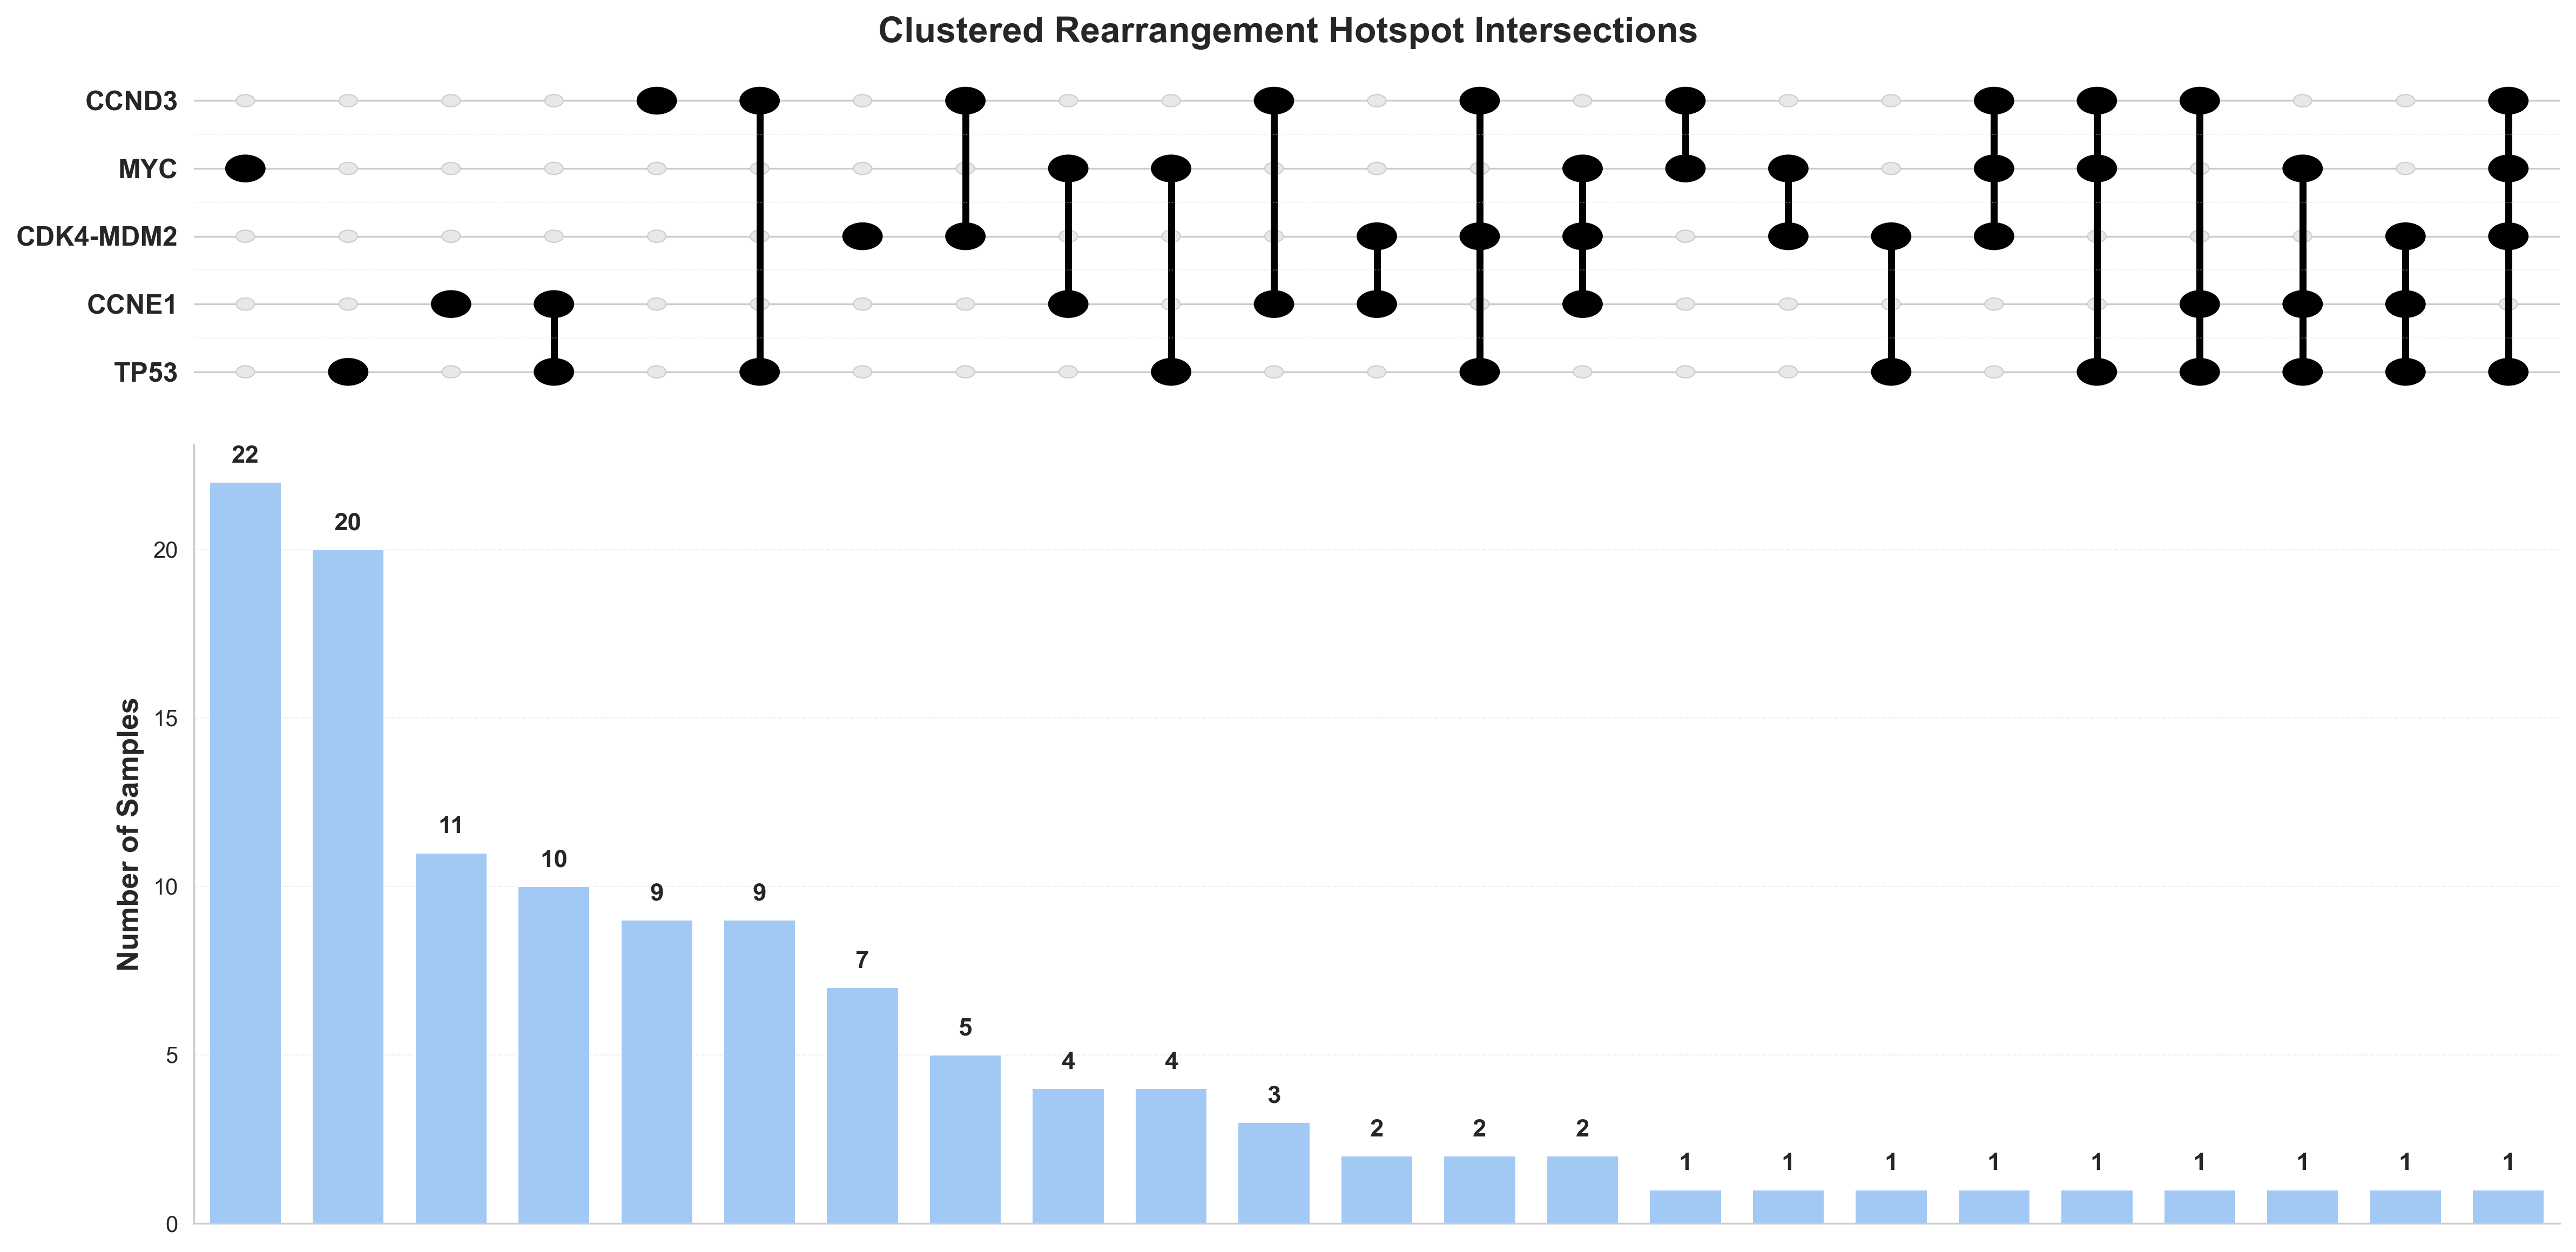

In [31]:
def create_upset_plot(matrix, filename):
    """
    Create an UpSet-style plot showing all intersections between events.
    """
    pastel_colors = sns.color_palette("pastel")
    pastel_blue = pastel_colors[0]  # pastel blue
    
    # Get all possible non-empty combinations
    all_combos = []
    for r in range(1, len(matrix.columns) + 1):
        for combo in combinations(matrix.columns, r):
            # Get samples with ALL the events in combo and NONE outside
            mask = (matrix[list(combo)] == 1).all(axis=1)
            for other in matrix.columns:
                if other not in combo:
                    mask &= (matrix[other] == 0)
            
            count = mask.sum()
            samples = matrix[mask].index.tolist()
            all_combos.append({
                'events': combo,
                'count': count,
                'samples': samples
            })
    
    # Sort by count descending
    all_combos = [c for c in all_combos if c['count'] > 0]
    all_combos.sort(key=lambda x: x['count'], reverse=True)
    
    # Create figure with two subplots
    fig = plt.figure(figsize=(16, 8))
    
    # Top: intersection matrix (make it larger proportion)
    ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=1)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    
    # Bottom: bar chart
    ax2 = plt.subplot2grid((3, 1), (1, 0), rowspan=2)
    
    # Draw bars with pastel blue - SAME x positions as matrix
    x_pos = np.arange(len(all_combos))
    counts = [c['count'] for c in all_combos]
    
    ax2.bar(x_pos, counts, color=pastel_blue, width=0.7, linewidth=0.5)
    ax2.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_xticks([])
    ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Add count labels on bars
    for i, v in enumerate(counts):
        ax2.text(i, v + max(counts)*0.02, str(v), ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    # Draw intersection matrix in top subplot - SAME x positions as bars
    events_list = list(matrix.columns)
    
    for i, combo_data in enumerate(all_combos):
        combo = combo_data['events']
        for j, event in enumerate(events_list):
            y_pos = len(events_list) - j - 1
            
            if event in combo:
                # Draw filled BLACK circle (smaller radius) - use SAME x position as bars
                circle = plt.Circle((i, y_pos), 0.18, 
                                   color='black', ec='black', linewidth=1.5, zorder=3)
                ax1.add_patch(circle)
                
                # Draw connecting lines between circles in same combination
                if len(combo) > 1:
                    event_positions = [len(events_list) - events_list.index(e) - 1 
                                     for e in combo]
                    event_positions.sort()
                    for k in range(len(event_positions) - 1):
                        ax1.plot([i, i], [event_positions[k], event_positions[k+1]], 
                                color='black', linewidth=3, solid_capstyle='round', zorder=2)
            else:
                # Draw light gray circle for not-included events (smaller radius)
                circle = plt.Circle((i, y_pos), 0.09, 
                                   color='#E8E8E8', ec='#CCCCCC', linewidth=0.5, zorder=1)
                ax1.add_patch(circle)
    
    x_min = -0.5
    x_max = len(all_combos) - 0.5
    
    ax1.set_xlim(x_min, x_max)
    ax2.set_xlim(x_min, x_max)
    
    # Set y limits and labels for top plot
    ax1.set_ylim(-0.8, len(events_list) - 0.2)
    ax1.set_yticks(range(len(events_list)))
    ax1.set_yticklabels(events_list[::-1], fontsize=12, fontweight='bold')
    ax1.set_xticks([])
    ax1.tick_params(left=False)
    
    # Add horizontal separator lines between genes for clarity
    for j in range(len(events_list) - 1):
        ax1.axhline(y=j + 0.5, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
    

    plt.suptitle('Clustered Rearrangement Hotspot Intersections', fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05)  # Reduce space between subplots
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    return fig

# Create the plot
matrix_analysis_plot = matrix_analysis[['CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1', 'TP53']]
fig = create_upset_plot(matrix_analysis_plot, '../results/hotspot_intersections.png')
plt.show()

In [ ]:
# create supplementary table
hotspot_cols = ['CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1', 'TP53']

sample_matrix = (
    final_df.groupby('sample')
      .agg(
          n_clustered_events=('event_idx', 'size'),
          **{col: (col, 'max') for col in hotspot_cols}  # 1 if any event hits the locus
      )
      .reset_index()
)

sample_matrix[hotspot_cols] = (sample_matrix[hotspot_cols] > 0).astype(int)

# full list of samples
all_samples = final_samples['tumor_normal_pair'].dropna().unique()

# columns that should be 0 for samples with no clustered SVs
count_cols = ['n_clustered_events'] + hotspot_cols
if 'n_hotspots_hit' in sample_matrix.columns:
    count_cols.append('n_hotspots_hit')

sample_matrix_full = (
    sample_matrix
      .set_index('sample')
      .reindex(all_samples)
      .fillna(0)
      .astype({col: int for col in count_cols})
      .rename_axis('sample')
      .reset_index()
)

print(sample_matrix_full['sample'].nunique())
sample_matrix_full.head()
sample_matrix_full.rename(columns={'n_clustered_events': 'number of clustered SV events', 'sample': 'sample_id'}, inplace=True)
# add 'event' after the name to the hotspot cols
sample_matrix_full.rename(columns={col: f'{col} event' for col in hotspot_cols}, inplace=True)
sample_matrix_full.head()

sv_counts = pd.read_csv('../../../SV_sample_data/data/clustered_and_nonclustered_sv_counts_by_sample.csv')
sv_counts.rename(columns={'sample': 'sample_id'}, inplace=True)

# merge the two dataframes on the sample_id column
sample_matrix_full = sample_matrix_full.merge(sv_counts, on='sample_id', how='left')
sample_matrix_full.head()
sample_matrix_full.rename(columns={'n_clustered': 'number of clustered SVs', 'n_non_clustered': 'number of non-clustered SVs'}, inplace=True)
sample_matrix_full = sample_matrix_full[['sample_id', 'number of clustered SVs', 'number of non-clustered SVs', 'number of clustered SV events', 'CCND3 event', 'MYC event', 'CDK4-MDM2 event', 'CCNE1 event', 'TP53 event']]
sample_matrix_full.to_csv('../results/clustered_sv_final_matrix.csv', index=False)
sample_matrix_full.head()

236


,sample_id,number of clustered SVs,number of non-clustered SVs,number of clustered SV events,CCND3 event,MYC event,CDK4-MDM2 event,CCNE1 event,TP53 event
0,09T02-09N01,210.0,222.0,5,0,1,0,0,0
1,09T03-09N01,122.0,115.0,3,0,0,0,0,0
2,10T03-10N02,186.0,90.0,2,0,0,0,0,0
3,13T02-13N02,162.0,261.0,2,0,0,1,1,0
4,17_439_00067_T2-17_439_00067_WB,189.0,310.0,2,0,0,0,0,0
